<a href="https://colab.research.google.com/github/Abhinav10067/Wind-turbine-efficiency/blob/DA/Wind_Turbine_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import  seaborn as sns

**The wind farm operator wants to monitor and predict the efficiency of the turbines received from the sensors.**

In [ ]:
df = pd.read_csv('/wind turbine train.csv')


In [ ]:
df


,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340899,2021-10-15 20:22:00,2.340531,2.685943,34.365458,867.222168,51.673977,1.271363,33.733278,33.237688,2.564865,1.982006,171.400350,3.383563,0.317134,Turbine_158,48.339401
340900,2021-12-17 22:49:00,1346.626770,1388.168091,28.888992,1199.168872,61.910533,1375.895671,28.945129,24.820398,233.429286,285.681844,36.803480,11.035374,0.583027,Turbine_158,42.733884
340901,2021-01-11 08:33:00,134.815271,130.339355,23.515354,769.073669,44.161268,125.238504,24.278432,23.331726,84.310106,97.634874,238.535764,4.298760,0.262570,Turbine_108,44.204813
340902,2021-03-20 06:59:00,370.991959,374.950445,14.892902,891.637177,57.479168,304.506887,32.343431,29.390462,87.964419,111.901437,255.758362,5.500029,0.472865,Turbine_19,43.971649


In [ ]:
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [ ]:
df.tail()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
340899,2021-10-15 20:22:00,2.340531,2.685943,34.365458,867.222168,51.673977,1.271363,33.733278,33.237688,2.564865,1.982006,171.400350,3.383563,0.317134,Turbine_158,48.339401
340900,2021-12-17 22:49:00,1346.626770,1388.168091,28.888992,1199.168872,61.910533,1375.895671,28.945129,24.820398,233.429286,285.681844,36.803480,11.035374,0.583027,Turbine_158,42.733884
340901,2021-01-11 08:33:00,134.815271,130.339355,23.515354,769.073669,44.161268,125.238504,24.278432,23.331726,84.310106,97.634874,238.535764,4.298760,0.262570,Turbine_108,44.204813
340902,2021-03-20 06:59:00,370.991959,374.950445,14.892902,891.637177,57.479168,304.506887,32.343431,29.390462,87.964419,111.901437,255.758362,5.500029,0.472865,Turbine_19,43.971649
340903,2021-12-03 21:34:00,919.435679,939.092773,29.603963,119.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340904 entries, 0 to 340903
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               340904 non-null  object 
 1   active_power_calculated_by_converter    340904 non-null  float64
 2   active_power_raw                        340904 non-null  float64
 3   ambient_temperature                     340904 non-null  float64
 4   generator_speed                         340904 non-null  float64
 5   generator_winding_temp_max              340903 non-null  float64
 6   grid_power10min_average                 340903 non-null  float64
 7   nc1_inside_temp                         340903 non-null  float64
 8   nacelle_temp                            340903 non-null  float64
 9   reactice_power_calculated_by_converter  340903 non-null  float64
 10  reactive_power                          3409

In [ ]:
df.isnull().sum()

,0
timestamp,0
active_power_calculated_by_converter,0
active_power_raw,0
ambient_temperature,0
generator_speed,0
generator_winding_temp_max,1
grid_power10min_average,1
nc1_inside_temp,1
nacelle_temp,1
reactice_power_calculated_by_converter,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

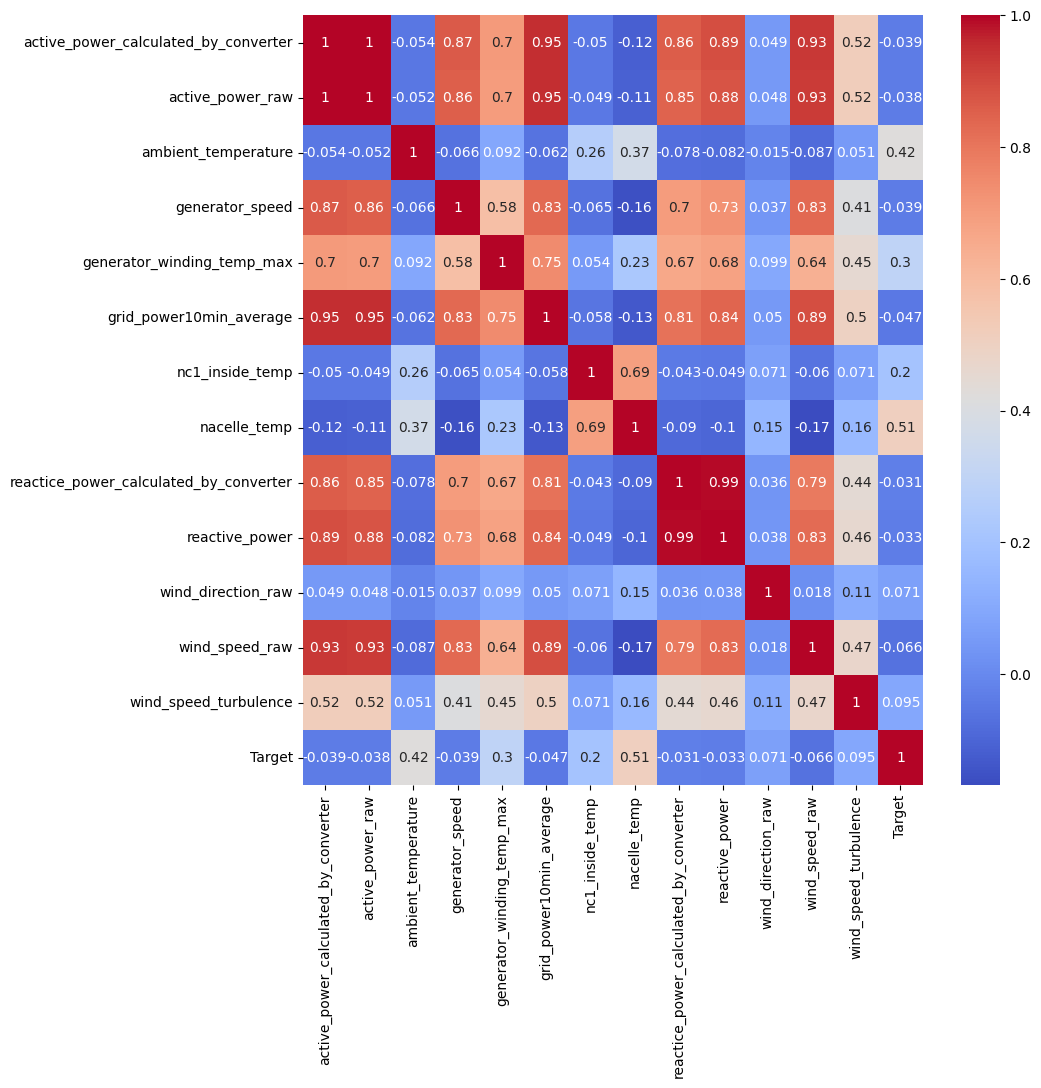

In [ ]:
# Creating a heatmap to check multicollinearity

plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only= True),annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# code for VIF and exclude the target column

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
col_list = []
for i in df.columns:
  if(df[i].dtypes == 'float64' and i!='Target'):
    col_list.append(i)

col_list


['active_power_calculated_by_converter',
 'active_power_raw',
 'ambient_temperature',
 'generator_speed',
 'generator_winding_temp_max',
 'grid_power10min_average',
 'nc1_inside_temp',
 'nacelle_temp',
 'reactice_power_calculated_by_converter',
 'reactive_power',
 'wind_direction_raw',
 'wind_speed_raw',
 'wind_speed_turbulence']

In [ ]:
x = df[col_list]
x

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340898,1695.354614,1750.376770,34.873137,1196.092651,90.549182,1990.070028,34.702756,34.389234,346.504786,407.137950,316.373596,9.317897,1.068161
340899,2.340531,2.685943,34.365458,867.222168,51.673977,1.271363,33.733278,33.237688,2.564865,1.982006,171.400350,3.383563,0.317134
340900,1346.626770,1388.168091,28.888992,1199.168872,61.910533,1375.895671,28.945129,24.820398,233.429286,285.681844,36.803480,11.035374,0.583027
340901,134.815271,130.339355,23.515354,769.073669,44.161268,125.238504,24.278432,23.331726,84.310106,97.634874,238.535764,4.298760,0.262570


In [ ]:
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0     active_power_calculated_by_converter  401.869362
1                         active_power_raw  363.731096
2                      ambient_temperature   13.174660
3                          generator_speed   76.425421
4               generator_winding_temp_max  127.493447
5                  grid_power10min_average   31.015780
6                          nc1_inside_temp  140.370863
7                             nacelle_temp  256.385783
8   reactice_power_calculated_by_converter  331.259882
9                           reactive_power  430.559253
10                      wind_direction_raw    4.828935
11                          wind_speed_raw   75.319212
12                   wind_speed_turbulence    7.885827


In [ ]:
df=df.drop(columns=['reactive_power','active_power_calculated_by_converter','nacelle_temp','generator_winding_temp_max','wind_speed_raw'])

In [ ]:
col_list = []
for i in df.columns:
  if(df[i].dtypes == 'float64' and i!='Target'):
    col_list.append(i)

col_list

x = df[col_list]
x

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  31.253979
1                     ambient_temperature  11.942248
2                         generator_speed  49.470937
3                 grid_power10min_average  23.734036
4                         nc1_inside_temp  42.738108
5  reactice_power_calculated_by_converter  10.586232
6                      wind_direction_raw   4.665357
7                   wind_speed_turbulence   7.363963
